# Análise Exploratória do Brasileirão

Bem-vindo à exploração de dados do desafio FBref! Neste notebook, vamos investigar:
1. Qual o jogador com o melhor **Gols por 90 minutos**?
2. Qual equipe **mais cede gols** aos adversários?

Vamos usar a base analítica gerada em `parquet` para tirar proveito dos MultiIndex do Pandas nativamente.

In [6]:
import pandas as pd
import pyarrow.parquet as pq

# Configurar o pandas para mostrar todas as colunas se necessário
pd.set_option('display.max_columns', None)

## 1. Melhor Gols por 90 minutos

In [7]:
# Carregar estatísticas de jogadores do Parquet
df_players = pd.read_parquet('../data/parquet/player_stats.parquet')

# Inspecionar o formato MultiIndex das colunas
display(df_players.head(3))

nation pos     age  born  \
                                                                         
league      season team         player                                   
BRA-Serie A 2026   Athletico–PR Arthur Dias      BRA  DF  19-074  2007   
                                Bruninho         BRA  MF  17-311  2008   
                                Bruno Zapelli    ARG  MF  24-037  2002   

                                              Playing Time                     \
                                                        MP Starts   Min   90s   
league      season team         player                                          
BRA-Serie A 2026   Athletico–PR Arthur Dias             17     17  1492  16.6   
                                Bruninho                 9      3   312   3.5   
                                Bruno Zapelli           15      8   683   7.6   

                                              Performance                  \
                                                      Gls Ast G+A G-PK PK   
league      season team         player                                      
BRA-Serie A 2026   Athletico–PR Arthur Dias             0   0   0    0  0   
                                Bruninho                0   0   0    0  0   
                                Bruno Zapelli           0   1   1    0  0   

                                                              Per 90 Minutes  \
                                              PKatt CrdY CrdR            Gls   
league      season team         player                                         
BRA-Serie A 2026   Athletico–PR Arthur Dias       0    5    0            0.0   
                                Bruninho          0    0    0            0.0   
                                Bruno Zapelli     0    4    1            0.0   

                                                                       
                                                Ast   G+A G-PK G+A-PK  
league      season team         player                                 
BRA-Serie A 2026   Athletico–PR Arthur Dias     0.0   0.0  0.0    0.0  
                                Bruninho        0.0   0.0  0.0    0.0  
                                Bruno Zapelli  0.13  0.13  0.0   0.13

In [8]:
# 1. Filtrar jogadores que atuaram no mínimo 500 minutos (para evitar distorções de amostras pequenas)
min_minutes = 500

# Atenção: O soccerdata coloca league, season, team, player como índices, vamos resetar o index para ficar mais fácil:
df_players_flat = df_players.reset_index()

# Vamos checar as novas colunas
display(df_players_flat.head(1))

league season          team       player nation pos     age  born  \
                                                                            
0  BRA-Serie A   2026  Athletico–PR  Arthur Dias    BRA  DF  19-074  2007   

  Playing Time                    Performance                                  \
            MP Starts   Min   90s         Gls Ast G+A G-PK PK PKatt CrdY CrdR   
0           17     17  1492  16.6           0   0   0    0  0     0    5    0   

  Per 90 Minutes                        
             Gls  Ast  G+A G-PK G+A-PK  
0            0.0  0.0  0.0  0.0    0.0

In [9]:
# Definindo o mapeamento exato das colunas a partir do MultiIndex
col_player = ('player', '')
col_team = ('team', '')
col_minutes = ('Playing Time', 'Min')
col_xg90 = ('Per 90 Minutes', 'Gls') # Em 2026 a FBref pode não disponibilizar xG na base gratuita padrão do Brasileirão

# Filtro para jogar os anômalos fora (> 500 minutos)
df_filtered = df_players_flat[df_players_flat[col_minutes] > min_minutes]

# Ordenando do maior para o menor Gols/90
top_xg = df_filtered.sort_values(by=col_xg90, ascending=False)

# Exibindo o Top 10
top_xg[[col_player, col_team, col_minutes, col_xg90]].head(10)

,player,team,Playing Time,Per 90 Minutes
,,,Min,Gls
477,Gabriel Barbosa,Santos,814,0.77
176,Breno,Coritiba,973,0.74
272,John Kennedy,Fluminense,1089,0.74
518,Ferreira,São Paulo,517,0.7
254,Pedro,Flamengo,1337,0.67
602,Renê Sousa,Vitória,682,0.66
17,Kevin Viveros,Athletico–PR,1517,0.65
92,Danilo Santos,Botafogo–RJ,1070,0.59
292,Carlos Vinícius,Grêmio,1379,0.59


## 2. Análise Defensiva de Equipes

Para isso, vamos usar o arquivo `schedule.parquet` para calcular quantos gols cada equipe sofreu, já que algumas bases do FBref podem não entregar métricas 'Against' por padrão dependendo da liga e ano.

In [10]:
df_schedule = pd.read_parquet('../data/parquet/schedule.parquet')
df_schedule = df_schedule.dropna(subset=['score'])

# O placar (score) tem o formato '2–1' (onde o primeiro é o mandante)
df_schedule[['home_goals', 'away_goals']] = df_schedule['score'].str.split('–', expand=True).astype(float)

# Calculando gols sofridos como Mandante
home_defense = df_schedule.groupby('home_team')['away_goals'].sum().reset_index()
home_defense.columns = ['team', 'goals_conceded']

# Calculando gols sofridos como Visitante
away_defense = df_schedule.groupby('away_team')['home_goals'].sum().reset_index()
away_defense.columns = ['team', 'goals_conceded']

# Somando os dois para ter o Total de Gols Sofridos
df_defense = pd.concat([home_defense, away_defense]).groupby('team').sum().reset_index()
df_defense = df_defense.sort_values(by='goals_conceded', ascending=False)

display(df_defense.head(10))

,team,goals_conceded
4,Chapecoense,33.0
3,Botafogo–RJ,31.0
18,Vasco da Gama,29.0
16,Santos,29.0
15,Remo,29.0
7,Cruzeiro,28.0
19,Vitória,25.0
6,Coritiba,24.0
12,Mirassol,24.0
9,Fluminense,23.0


---
## 3. Visualizações de Dados 📊

Agora vamos explorar visualmente os dados coletados criando diversos gráficos usando `matplotlib` e `seaborn`.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Gráfico 1: Top 10 Artilheiros por 90 Minutos
Mostra de forma ranqueada quem são os matadores da liga em proporção ao tempo jogado.

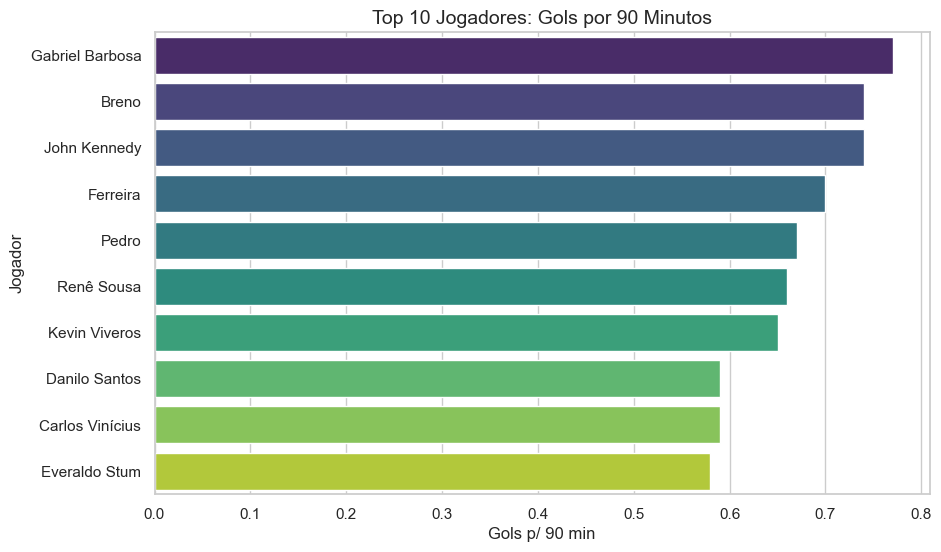

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_xg.head(10), x=col_xg90, y=col_player, palette="viridis")
plt.title("Top 10 Jogadores: Gols por 90 Minutos", fontsize=14)
plt.xlabel("Gols p/ 90 min", fontsize=12)
plt.ylabel("Jogador", fontsize=12)
plt.show()

### Gráfico 2: Gols vs Assistências (Visão Geral de Playmakers)
Quem participa mais ativamente em gols? (Apenas quem tem minutos consideráveis)

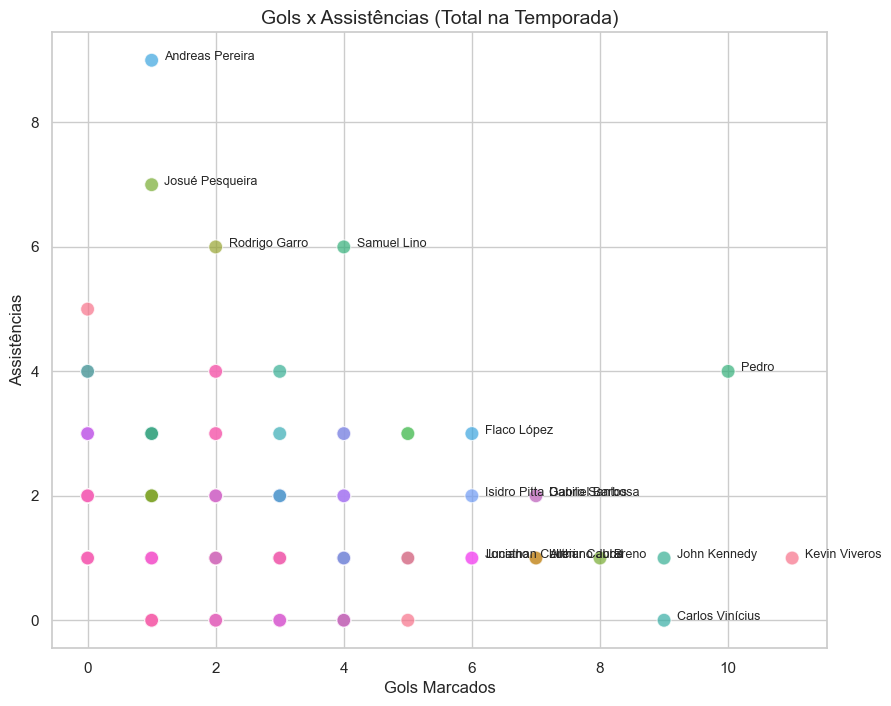

In [13]:
col_ast = ('Performance', 'Ast')
col_gls = ('Performance', 'Gls')

# Filtramos para ver apenas jogadores com pelo menos 1 gol ou 1 assistência
df_playmakers = df_filtered[(df_filtered[col_gls] > 0) | (df_filtered[col_ast] > 0)]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_playmakers, x=col_gls, y=col_ast, hue=col_team, s=100, alpha=0.7, legend=False)
plt.title("Gols x Assistências (Total na Temporada)", fontsize=14)
plt.xlabel("Gols Marcados", fontsize=12)
plt.ylabel("Assistências", fontsize=12)

# Adicionar rótulos para os jogadores muito acima da média
for i in range(df_playmakers.shape[0]):
    gls = df_playmakers[col_gls].iloc[i]
    ast = df_playmakers[col_ast].iloc[i]
    if gls > 5 or ast > 5:
        plt.text(gls + 0.2, ast, df_playmakers[col_player].iloc[i], fontsize=9)

plt.show()

### Gráfico 3: Distribuição de Idades na Série A
Como é o perfil de idade dos jogadores atuando ativamente no campeonato?

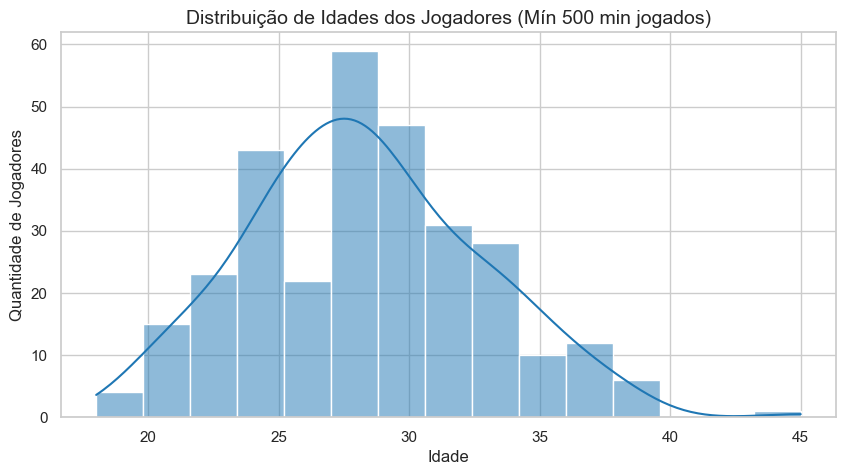

In [14]:
col_age = ('age', '')
# A idade vem como string ex: '25-143', vamos separar pelo hífen e pegar só o ano
df_filtered['Idade'] = df_filtered[col_age].str.split('-').str[0].astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(data=df_filtered, x='Idade', bins=15, kde=True, color="#1f77b4")
plt.title("Distribuição de Idades dos Jogadores (Mín 500 min jogados)", fontsize=14)
plt.xlabel("Idade", fontsize=12)
plt.ylabel("Quantidade de Jogadores", fontsize=12)
plt.show()

### Gráfico 4: Piores Defesas (Gols Sofridos por Equipe)
Visualizando os dados que calculamos na parte 2.

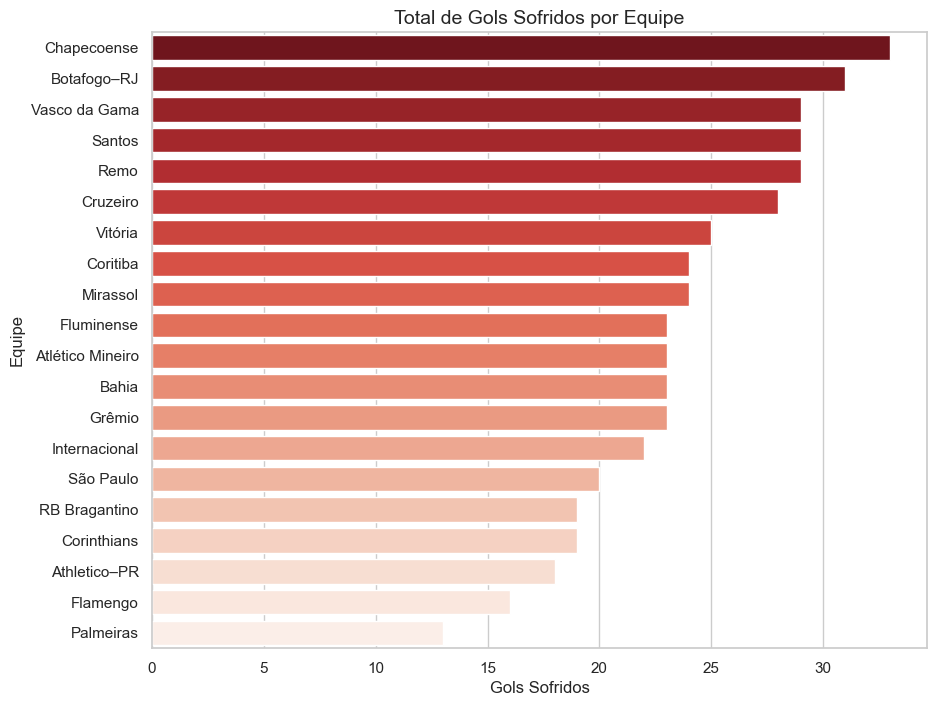

In [15]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df_defense, x='goals_conceded', y='team', palette="Reds_r")
plt.title("Total de Gols Sofridos por Equipe", fontsize=14)
plt.xlabel("Gols Sofridos", fontsize=12)
plt.ylabel("Equipe", fontsize=12)
plt.show()